# VisualAstro Styles Guide

visualastro comes with many matplotlib styles to use when making figures! Here is a quick tutorial on how to use them!

visualastro automatically registers all the packaged styles with matplotlib, so you do not need to import them! You are also
free to add as many styles as you want, by simply adding a `mynewstyle.mplstyle` style sheet in the `visualastro/src/visualastro/stylelib/` folder! Your style will then be available under the name `mynewstyle`. If you choose to modify visualastro, make sure you are doing so on a fork so that you don't lose your changes if you update the package!


In [1]:
import astropy.units as u
import numpy as np
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import visualastro as va

# set some defaults
va.config.figsize = (5, 5)
va.config.figsize3D = (4, 4)

To enable a style, use the `plt.style.use` method. This will set all matplotlib global style variables to whatever style you choose.
visualastro comes with many custom styles, which are listed in `va.styles.available`. You can also use any style from `scienceplots` https://github.com/garrettj403/SciencePlots, or any of the available matplotlib styles https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html !

## A Description of the Styles

### Font Styles
These change the font of your figure

#### Serif Fonts (Latex-Like)
* stix : StixGeneral Serif font
* libertinus : Libertinus Serif font
* computer-modern : Computer Modern Serif font
* dejavu : DejaVu Serif font
* times-new-roman : Times New Roman Serif font
* palantino : Palantino Serif font
* serif : generic serif font

#### Sans Serif Fonts
* stix-sans : StixGeneral Sans Serif font
* dejavu-sans : DejaVu Sans Serif font
* computer-modern-sans : Computer Modern Sans Serif font
* helvetica : Helvetica Sans Serif font
* arial : Arial Sans Serif font
* sans-serif : generic sans serif font

#### Monospaced Fonts (Typewriter)
* computer-modern-mono : Computer Modern Unicode TypeWriter font
* concrete : Concrete Math Monospace font
* concrete-bold : Concrete Math Bold Monospace font
* courier : Courier Monospace font
* courier-new : Courier New Monospace font
* dejavu-mono : DejaVu Monospace font
* hershey : AVHershey Truetype font (Supermongo font)
* mono : generic monospace font

### Axes Styles
These change the axes style of your figure
* full : Apply major and minor ticks facing in on all axes splines
* minimal : Apply major ticks facing out on only the left and bottom axes splines

In [2]:
# we can update all our plots to use the STIXGeneral font
plt.style.use('stix')

In [3]:
# create some data
x = np.linspace(0, 5, 500)
y = np.linspace(0, 5, 500)
X, Y = np.meshgrid(x, y)

with np.errstate(invalid='ignore', divide='ignore'):
    Z = 1/np.sin(np.tan(10/X**Y)) - 1/np.sin(np.tan(10/Y**X))

# let's define some more data
r_p = 1.0
theta = np.linspace(0, 2 * np.pi, 500)
e_vals = [0.0, 0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 0.95, 1.4, 1.5, 2]
a_vals = [r_p / (1 - e) for e in e_vals]
r_vals = [a * (1 - e**2) / (1 + e * np.cos(theta)) for (a, e) in zip(a_vals, e_vals)]
x_vals = [r * np.cos(theta) for r in r_vals]
y_vals = [r * np.sin(theta) for r in r_vals]

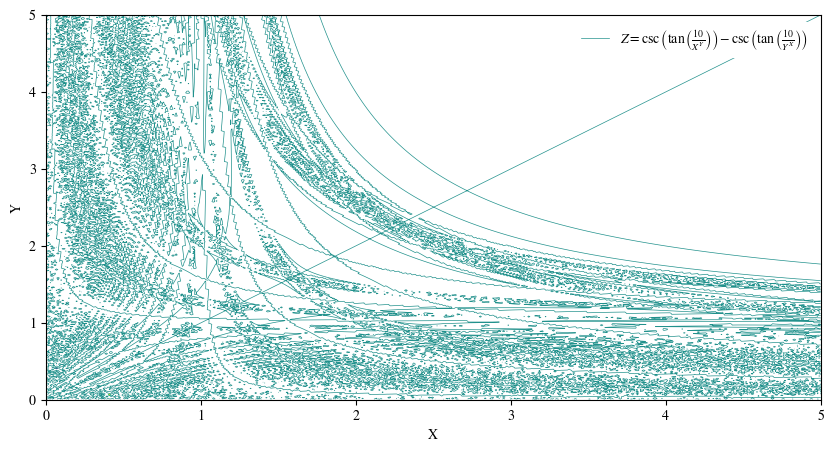

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
label = r'$Z = \csc\left(\tan\left(\frac{10}{X^Y}\right)\right) - \csc\left(\tan\left(\frac{10}{Y^X}\right)\right)$'

CS = ax.contour(X, Y, Z, linewidths=0.5, cmap='viridis')

va.legend(
    handles=[Line2D([0], [0], color=CS.cmap(0.5), lw=CS.get_linewidth()[0], label=label)],
    loc='upper right',
    frameon=True
)
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.show()

As you can see, we are now using the AVHershey fonts used in the supermongo plotting package!

We can also apply style(s) temporarily using `plt.style.context` instead! Everything inside of the `with` block will have the style applied.
It is also possible to chain styles together! The rightmost style takes precedence in the event of conflicting parameters.

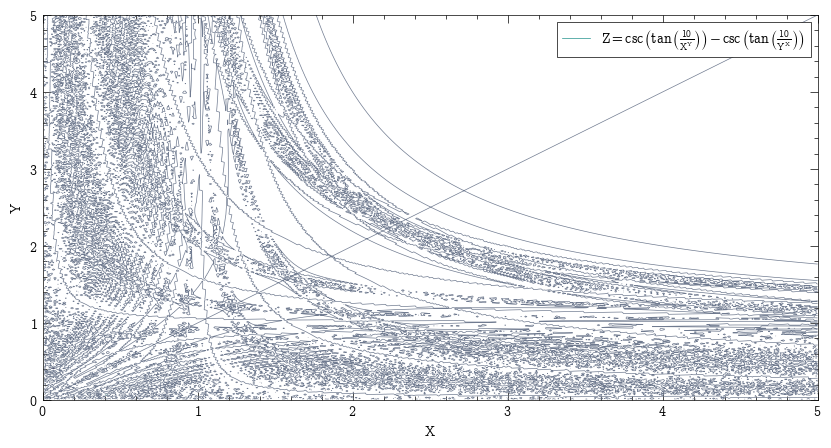

In [5]:
with plt.style.context(['full', 'concrete']):
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.contour(X, Y, Z, linewidths=0.5, cmap='bone')
    va.legend(
        handles=[Line2D([0], [0], color=CS.cmap(0.5), lw=CS.get_linewidth()[0], label=label)],
        loc='upper right',
        frameon=True,
        edgecolor='k',    
    )
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    plt.show()

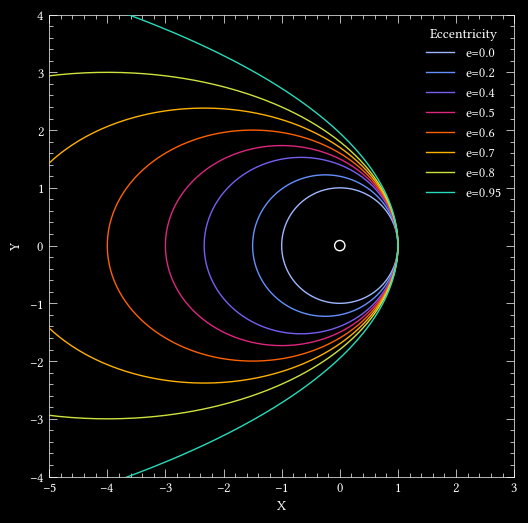

In [6]:
colors = va.get_colors('astro_seq')
labels = [f'e={e}' for e in e_vals]
with plt.style.context(['full', 'dark_background', 'libertinus']):
    fig, ax = plt.subplots(figsize=(6,6))

    va.plot(
        x_vals[:8], y_vals[:8], ax=ax, 
        label=labels, color=colors, lw=1, 
        xlim=(-5, 3), ylim=(-4, 4),
        xlabel='X', ylabel='Y'
    )

    ax.scatter(0, 0, color='w', fc='none', s=55)

    plt.legend(loc='upper right', title='Eccentricity')

    plt.show()

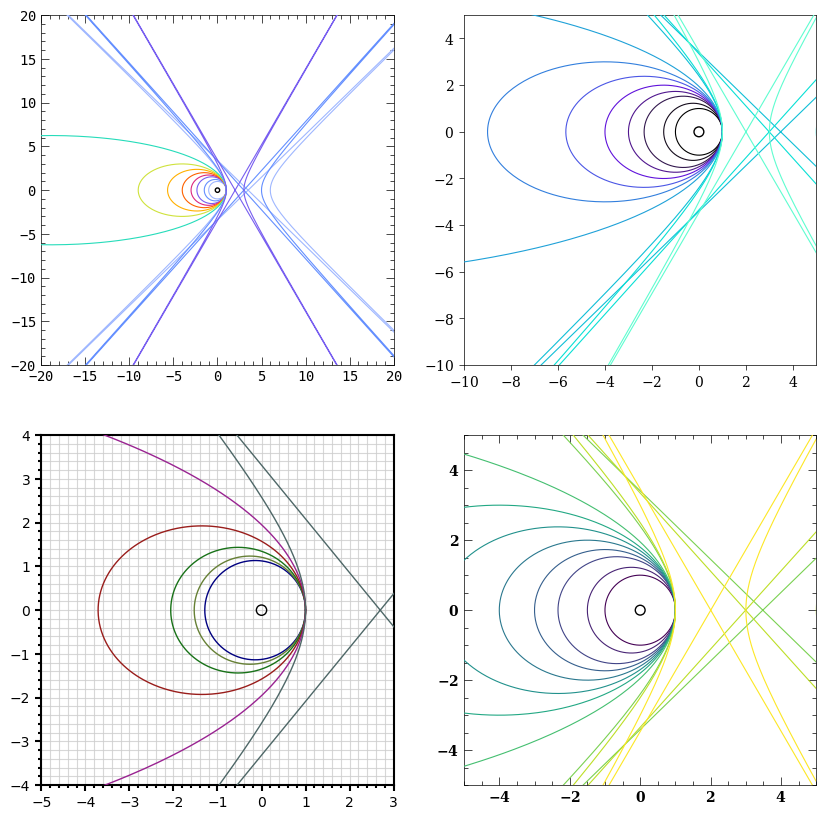

In [18]:
fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(2, 2)

with plt.style.context(['full', 'cm-mono']):
    ax1 = fig.add_subplot(gs[0, 0])
    va.scatter(0, 0, color='k', fc='none', s=10, ax=ax1)
    va.plot(x_vals, y_vals, limits=20, color='astro_seq', ax=ax1)

with plt.style.context(['minimal', 'libertinus']):
    ax2 = fig.add_subplot(gs[0, 1])
    va.scatter(0, 0, color='k', fc='none', s=50, ax=ax2)
    va.plot(x_vals, y_vals, limits=[-10, 5], color=11, cmap='cosmic', ax=ax2)


with plt.style.context(['thorlabs']):
    ax3 = fig.add_subplot(gs[1, 0])
    va.plot_colorset('cardstock_dark', ax=ax3, legend=False)

with plt.style.context(['full', 'concrete-bold']):
    ax4 = fig.add_subplot(gs[1, 1])
    va.scatter(0, 0, color='k', fc='none', s=50, ax=ax4)
    va.plot(x_vals, y_vals, lim=5, color=11, cmap='viridis', ax=ax4)
plt.show()

### More Help With Styles

`va.styles` can list more than just the available styles!

In [8]:
# same as va.styles.fonts.available
va.styles.fonts

Fonts([
    'arial',
    'computer-modern',
    'computer-modern-mono',
    'computer-modern-sans',
    'concrete',
    'concrete-bold',
    'courier',
    'courier-new',
    'dejavu',
    'dejavu-mono',
    'dejavu-sans',
    'helvetica',
    'hershey',
    'libertinus',
    'mono',
    'palantino',
    'sans-serif',
    'serif',
    'stix',
    'stix-sans',
    'times-new-roman'
])

In [9]:
# print only serif styles
print('serif: \n', va.styles.fonts.serif)

# print only monospace styles
print('monospace: \n', va.styles.fonts.monospace)

# print only sans-serif styles
print('sans-serif: \n', va.styles.fonts.sansserif)

# print axes styles
print('axes: \n', va.styles.axes.available)

serif: 
 ['computer-modern', 'dejavu', 'libertinus', 'palantino', 'serif', 'stix', 'times-new-roman']
monospace: 
 ['computer-modern-mono', 'concrete', 'concrete-bold', 'courier', 'courier-new', 'dejavu-mono', 'hershey', 'mono']
sans-serif: 
 ['arial', 'computer-modern-sans', 'dejavu-sans', 'helvetica', 'sans-serif', 'stix-sans']
axes: 
 ['full', 'minimal']


Here are sample plots made with the available VisualAstro plot styles. 
Each style sets the axes, fonts and font sizes, but leaves the color up to the user.



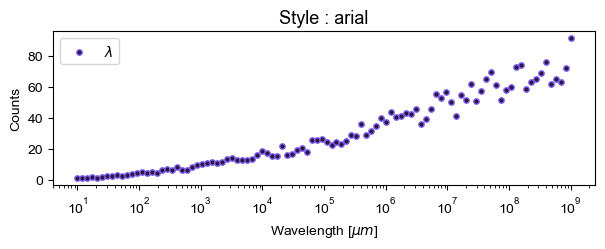

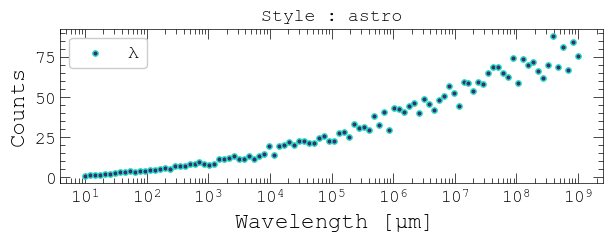

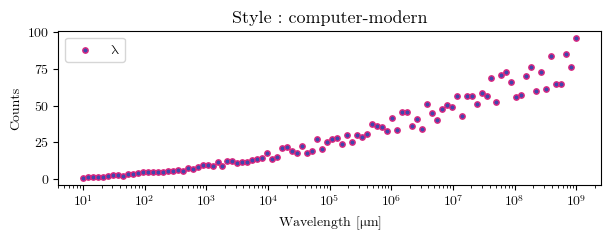

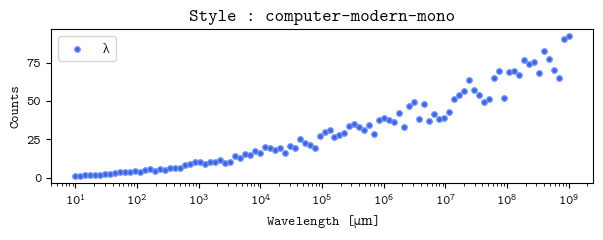

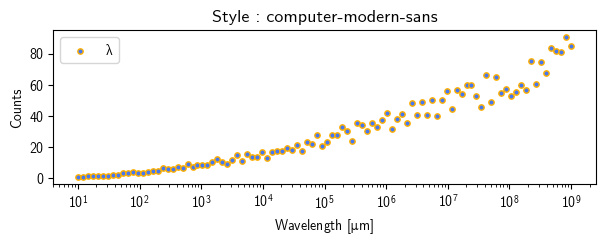

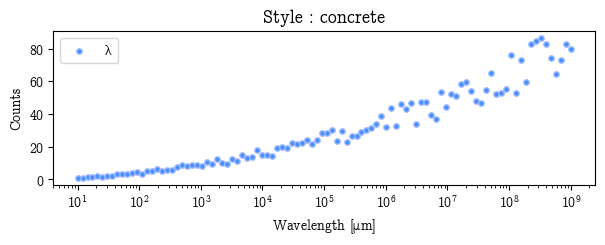

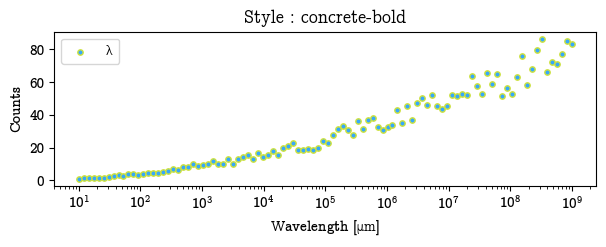

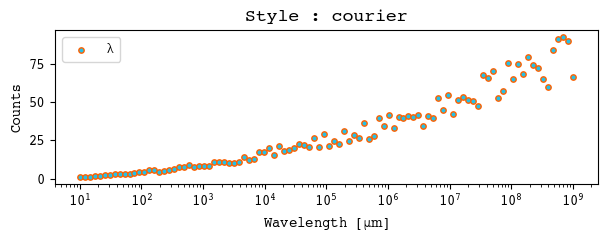

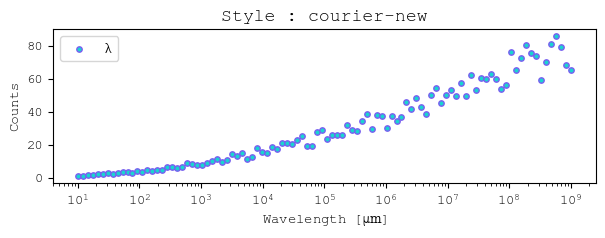

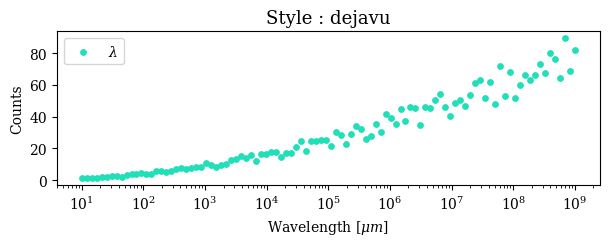

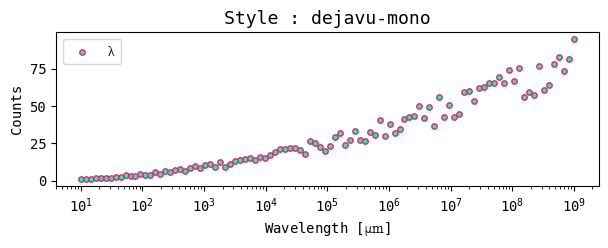

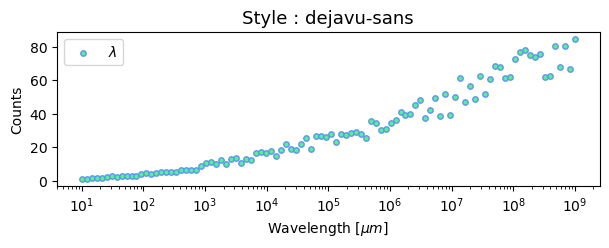

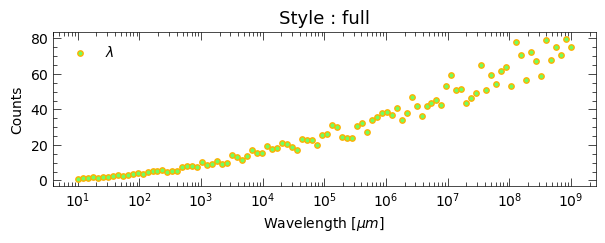

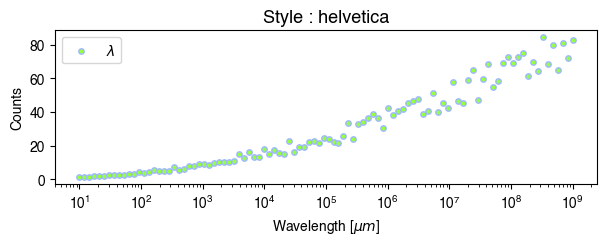

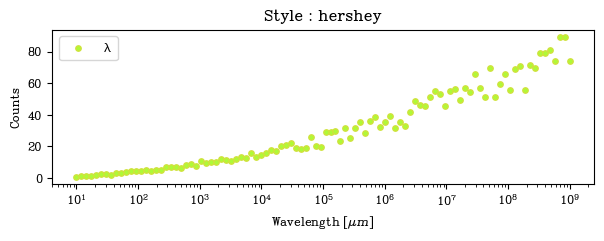

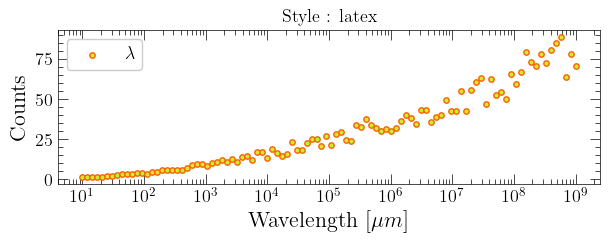

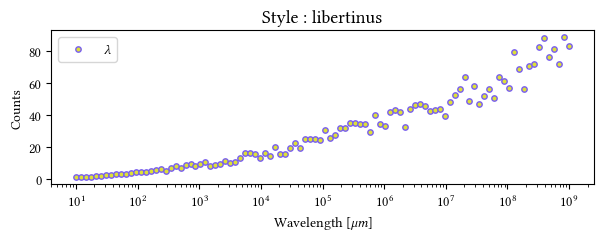

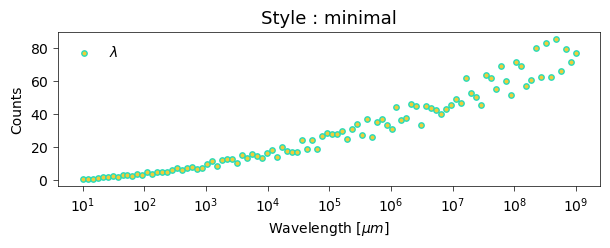

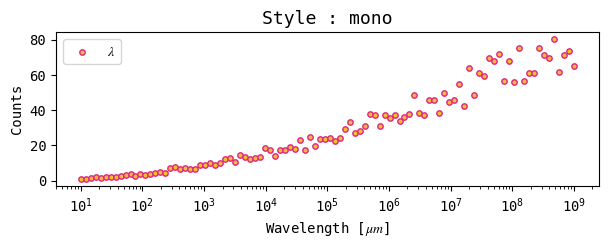

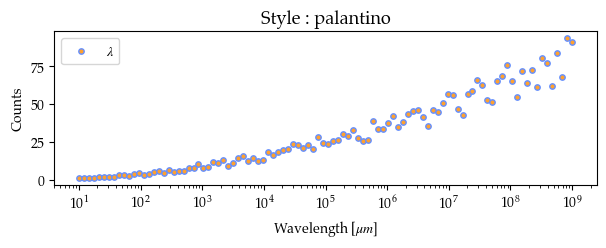

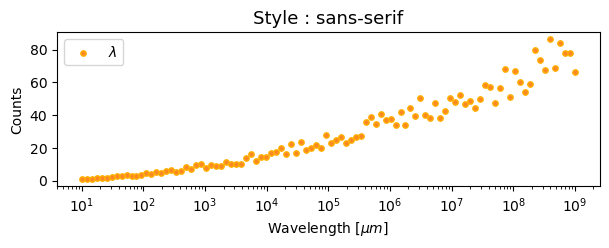

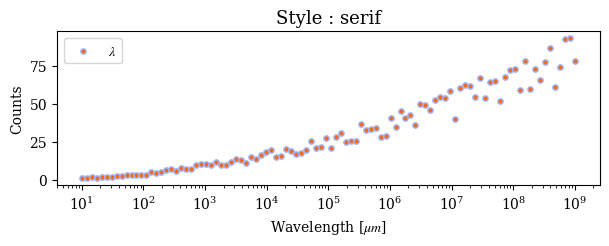

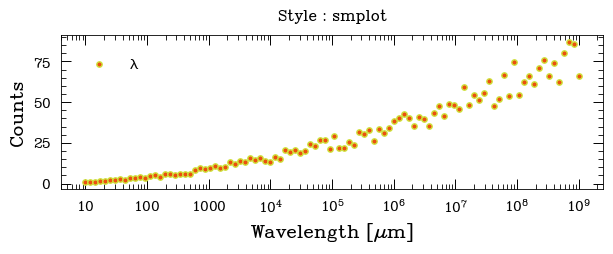

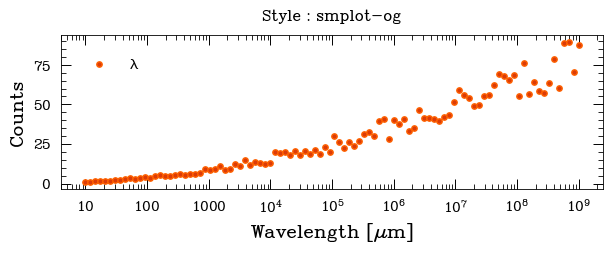

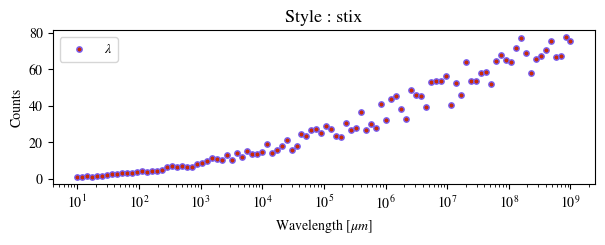

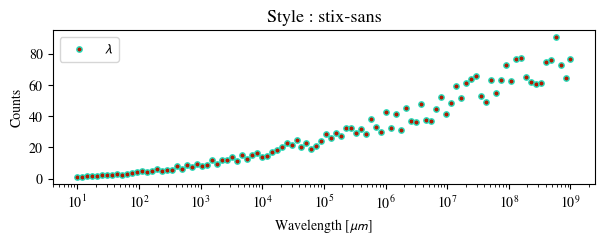

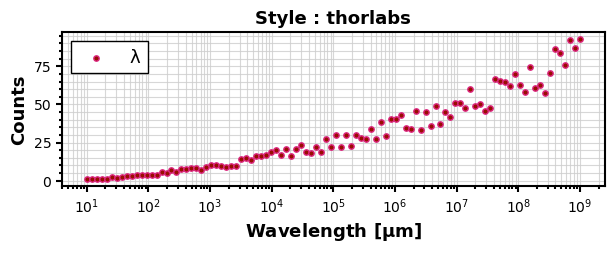

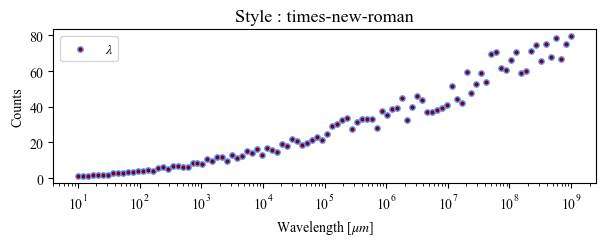

In [10]:
# Here are more styles
va.help.style()

### 3D Plot Styles

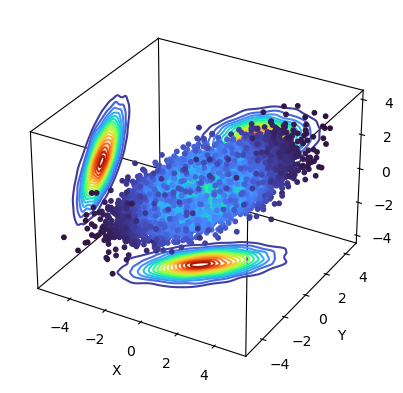

In [11]:
blob = va.blob(10000, as_array=True)
dens = va.number_density(blob, 2000)
va.config.cmap = 'turbo'
va.ax.scatter3D(blob, axis_style='cube', c=dens, plot_contours='all')

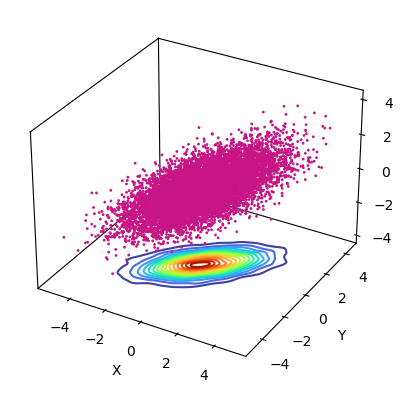

In [12]:
va.ax.scatter3D(blob, axis_style='panel', color='mediumvioletred', s=1, plot_contours='z')

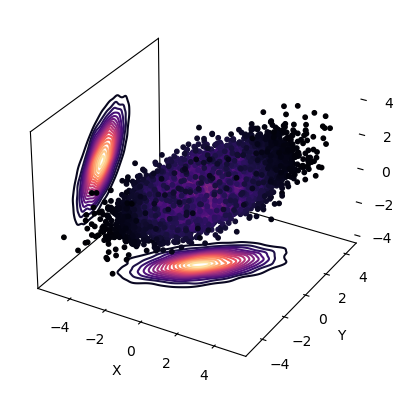

In [13]:
va.ax.scatter3D(blob, axis_style='y_panel', plot_contours=['x', 'z'], cmap='magma', c=dens)

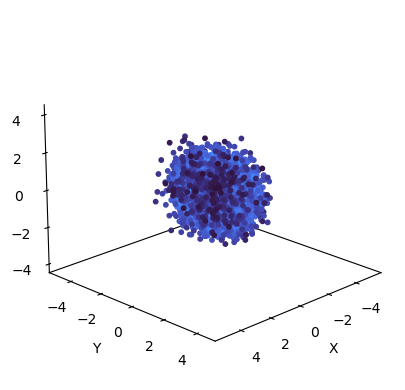

In [14]:
va.ax.scatter3D(blob, axis_style='floor', elev=20, azim=45, c=dens)

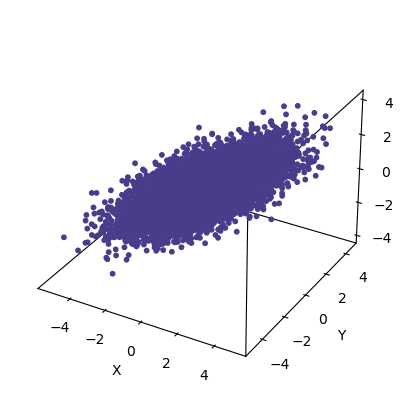

In [15]:
# some of the 3D styles can be reveresed 
va.ax.scatter3D(blob, axis_style='y_panel_r', color='darkslateblue')

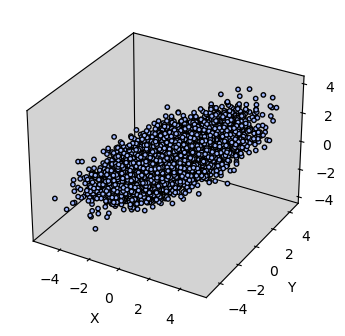

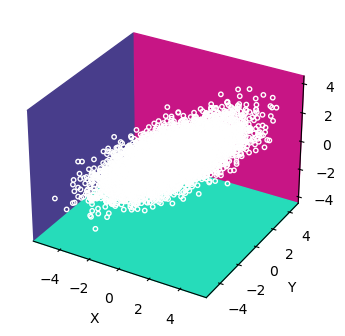

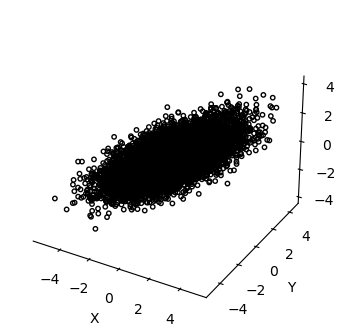

In [16]:
fig, ax = va.ax3d()
va.scatter3D(blob, ax=ax, ec='k')

va.ax3d_pane_color('lightgrey', ax=ax)
va.ax3d_axis_style(ax, 'panel')

plt.show()

fig, ax = va.ax3d()
va.scatter3D(blob, ax=ax, color='w', fc='none')

va.ax3d_pane_color(['darkslateblue', 'mediumvioletred', 'jade'], ax=ax)

plt.show()

fig, ax = va.ax3d()
va.scatter3D(blob, ax=ax, color='k', fc='none')

va.ax3d_axis_style(ax, None)

plt.show()

In [17]:
help(va.ax3d_axis_style)

Help on function ax3d_axis_style in module visualastro.plotting.core.axes:

ax3d_axis_style(ax: mpl_toolkits.mplot3d.axes3d.Axes3D, style: str | None = 'cube') -> None
    Set the spine style of a 3D matplotlib axes by drawing explicit edge lines.
    
    Overrides matplotlib axes rendering while keeping the ticks and tick labels.
    For this reason these styles are experimental and may break in interactive mode.
    
    The styles are defined with respect to the default matplotlib viewing angles of
    `elev=30`, `azim=-60`, and `roll=0`.
    
    Parameters
    ----------
    ax : Axes3D
        Target 3D axes object.
    style : str | None, optional, default='cube'
        Spine layout to apply.
    
        * `'triad'`        : 3 edges from the front-right-bottom corner (matplotlib default-like).
        * `'floor'`        : 4 bottom edges of the bounding box.
        * `'ceiling'`      : 4 top edges of the bounding box.
        * `'cube'`         : all 12 edges of the bounding 